In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(linewidth=120)


In [4]:
def sgn(x):
    """Bipolar sign used in the lab: sign(x)=+1 if x>=0 else -1"""
    return np.where(x >= 0, 1, -1)

def hebbian_weights(patterns, remove_self=True, scale_by_n=False):
    """
    patterns: array shape (P, N), bipolar {-1,+1}
    W = sum_mu x_mu^T x_mu  (outer-product sum)
    remove_self: set diagonal to 0
    scale_by_n: divide by N (optional; not required for small tasks per lab)
    """
    P, N = patterns.shape
    W = patterns.T @ patterns  # (N,P)@(P,N) -> (N,N)
    if scale_by_n:
        W = W / N
    if remove_self:
        np.fill_diagonal(W, 0.0)
    return W

def recall_sync(W, x0, max_steps=50):
    """
    Little model (synchronous): x_{t+1} = sign(W x_t)
    Returns: final state, trajectory (list), steps used
    """
    x = x0.copy()
    traj = [x.copy()]
    for t in range(max_steps):
        x_new = sgn(W @ x)
        traj.append(x_new.copy())
        if np.array_equal(x_new, x):
            return x_new, traj, t+1
        x = x_new
    return x, traj, max_steps

def recall_async(W, x0, n_updates=5000, random_order=True, seed=None, track_every=100):
    """
    Hopfield original (asynchronous): update one unit at a time using current state.
    n_updates counts single-neuron updates (not full sweeps).
    Returns: final state, snapshots (list of (update_index, state)), energy list (optional later)
    """
    rng = np.random.default_rng(seed)
    x = x0.copy()
    N = x.size
    
    snapshots = [(0, x.copy())]
    for k in range(1, n_updates+1):
        i = rng.integers(0, N) if random_order else (k-1) % N
        h_i = W[i, :] @ x
        x[i] = 1 if h_i >= 0 else -1
        if (k % track_every) == 0:
            snapshots.append((k, x.copy()))
    return x, snapshots

def energy(W, x):
    """
    Lab energy: E = - sum_i sum_j w_ij x_i x_j
    (No 1/2 in the lab statement; that’s fine for comparison.)
    """
    return - (x @ W @ x)

def hamming_distance(a, b):
    return np.mean(a != b)


In [5]:
x1 = np.array([-1,-1, 1,-1, 1,-1,-1, 1])
x2 = np.array([-1,-1,-1,-1,-1, 1,-1,-1])
x3 = np.array([-1, 1, 1,-1,-1, 1,-1, 1])

X = np.stack([x1,x2,x3], axis=0)
W = hebbian_weights(X, remove_self=True, scale_by_n=False)

print("W shape:", W.shape)
print("Diagonal:", np.diag(W))


W shape: (8, 8)
Diagonal: [0 0 0 0 0 0 0 0]


In [6]:
for k, x in enumerate([x1,x2,x3], start=1):
    x1step = sgn(W @ x)
    print(f"Pattern x{k} stable? {np.array_equal(x1step, x)}  |  one-step:", x1step)


Pattern x1 stable? True  |  one-step: [-1 -1  1 -1  1 -1 -1  1]
Pattern x2 stable? True  |  one-step: [-1 -1 -1 -1 -1  1 -1 -1]
Pattern x3 stable? True  |  one-step: [-1  1  1 -1 -1  1 -1  1]


In [7]:
x1d = np.array([ 1,-1, 1,-1, 1,-1,-1, 1])  # 1 bit error (per PDF)
x2d = np.array([ 1, 1,-1,-1,-1, 1,-1,-1])  # 2 bit errors
x3d = np.array([ 1, 1, 1,-1, 1, 1,-1, 1])  # 2 bit errors

distorted = [("x1d", x1d), ("x2d", x2d), ("x3d", x3d)]
memories  = [("x1", x1), ("x2", x2), ("x3", x3)]

def identify_memory(x, memories):
    for name, m in memories:
        if np.array_equal(x, m):
            return name
    return "other/spurious"

for name, xd in distorted:
    xf, traj, steps = recall_sync(W, xd, max_steps=30)
    print(f"{name}: converged in {steps} steps -> {identify_memory(xf, memories)}  final={xf}")


x1d: converged in 2 steps -> x1  final=[-1 -1  1 -1  1 -1 -1  1]
x2d: converged in 30 steps -> other/spurious  final=[ 1  1 -1 -1 -1  1 -1 -1]
x3d: converged in 30 steps -> other/spurious  final=[-1 -1  1 -1  1  1 -1  1]


In [8]:
def all_bipolar_states(N):
    # Generates all 2^N bipolar states in {-1,+1}
    states = np.array(np.meshgrid(*[[ -1, 1]]*N)).T.reshape(-1,N)
    return states

states = all_bipolar_states(8)

attractor_map = {}
for s in states:
    a, _, _ = recall_sync(W, s, max_steps=50)
    attractor_map[tuple(s)] = tuple(a)

attractors = sorted(set(attractor_map.values()))
print("Number of attractors found:", len(attractors))
print("Attractors:")
for a in attractors:
    print(np.array(a))
    


Number of attractors found: 64
Attractors:
[-1 -1 -1 -1 -1 -1 -1  1]
[-1 -1 -1 -1 -1  1 -1 -1]
[-1 -1 -1 -1 -1  1 -1  1]
[-1 -1 -1 -1  1  1 -1  1]
[-1 -1 -1  1 -1 -1  1  1]
[-1 -1 -1  1 -1  1  1 -1]
[-1 -1 -1  1  1  1  1  1]
[-1 -1  1 -1 -1 -1 -1 -1]
[-1 -1  1 -1 -1 -1 -1  1]
[-1 -1  1 -1 -1  1 -1 -1]
[-1 -1  1 -1  1 -1 -1  1]
[-1 -1  1 -1  1  1 -1 -1]
[-1 -1  1 -1  1  1 -1  1]
[-1 -1  1  1 -1 -1  1 -1]
[-1 -1  1  1 -1  1  1  1]
[-1 -1  1  1  1 -1  1  1]
[-1 -1  1  1  1  1  1 -1]
[-1  1 -1 -1 -1 -1  1  1]
[-1  1 -1 -1 -1  1  1 -1]
[-1  1 -1 -1  1 -1  1 -1]
[-1  1 -1 -1  1  1  1  1]
[-1  1 -1  1 -1 -1 -1  1]
[-1  1 -1  1 -1  1 -1 -1]
[-1  1 -1  1  1 -1 -1 -1]
[-1  1 -1  1  1  1 -1  1]
[-1  1  1 -1 -1 -1  1 -1]
[-1  1  1 -1 -1  1 -1  1]
[-1  1  1 -1  1 -1  1  1]
[-1  1  1 -1  1  1  1 -1]
[-1  1  1  1 -1 -1 -1 -1]
[-1  1  1  1  1 -1 -1  1]
[-1  1  1  1  1  1 -1 -1]
[ 1 -1 -1 -1 -1 -1  1  1]
[ 1 -1 -1 -1 -1  1  1 -1]
[ 1 -1 -1 -1  1  1  1  1]
[ 1 -1 -1  1 -1 -1 -1  1]
[ 1 -1 -1  1 -1  1 -1

In [9]:
def flip_bits(x, nflip, seed=0):
    rng = np.random.default_rng(seed)
    y = x.copy()
    idx = rng.choice(len(x), size=nflip, replace=False)
    y[idx] *= -1
    return y

# Example: flip 5 of 8 bits (> half)
start = flip_bits(x1, 5, seed=1)
xf, traj, steps = recall_sync(W, start, max_steps=50)
print("Start:", start)
print("Final:", xf, "steps:", steps, "->", identify_memory(xf, memories))


Start: [ 1  1 -1 -1 -1 -1  1  1]
Final: [ 1  1 -1  1 -1 -1  1  1] steps: 50 -> other/spurious


In [17]:
import os
import pandas as pd

path = "pict.dat"
if not os.path.exists(path):
    print("ERROR: pict.dat not found in current folder. Put pict.dat next to the notebook.")
else:
    data = pd.read_csv(path, header=None).values
    print("Loaded raw shape:", data.shape)

Loaded raw shape: (1, 11264)


In [18]:
data = data.reshape((-1, 1024))

import matplotlib.pyplot as plt

def display_pattern(pattern: np.ndarray, filename: str):
    pattern = pattern.reshape(32, 32).T
    plt.imshow(pattern, interpolation="nearest", cmap="gray")
    plt.title("Pattern")
    plt.savefig(filename, bbox_inches="tight")
    plt.show()



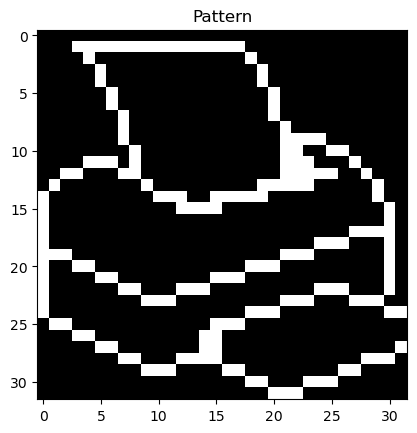

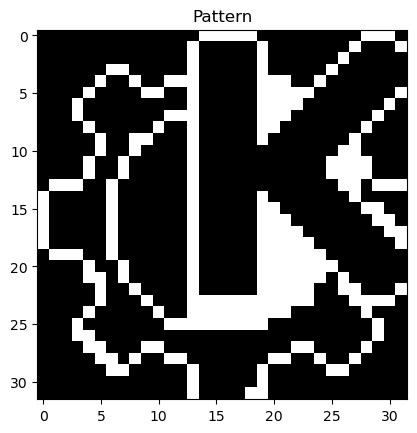

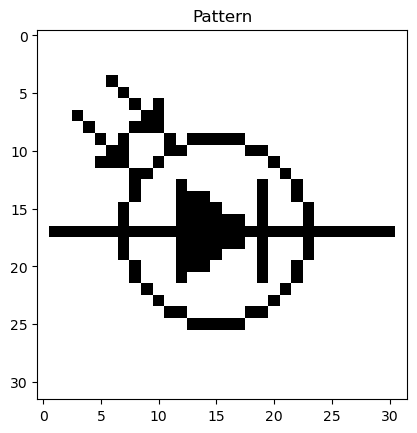

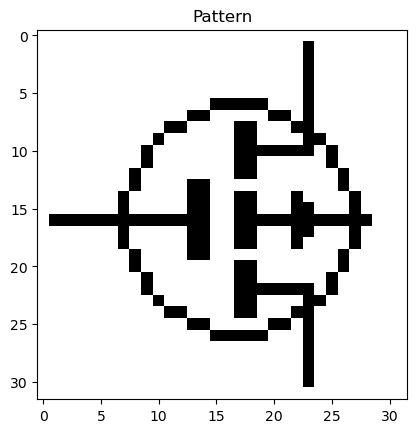

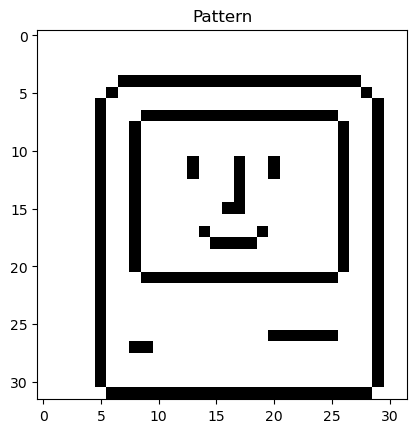

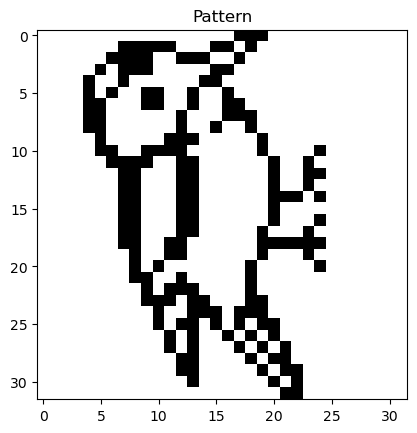

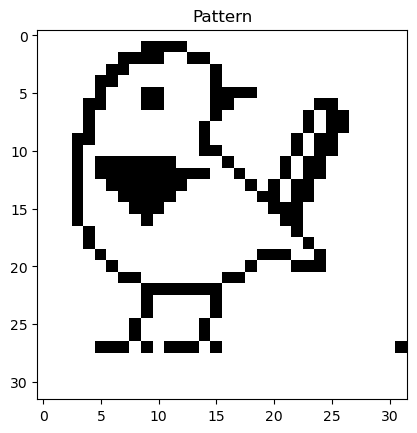

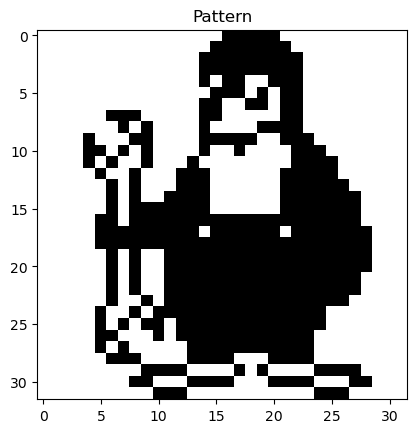

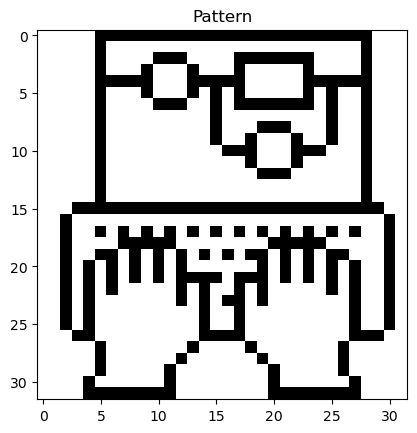

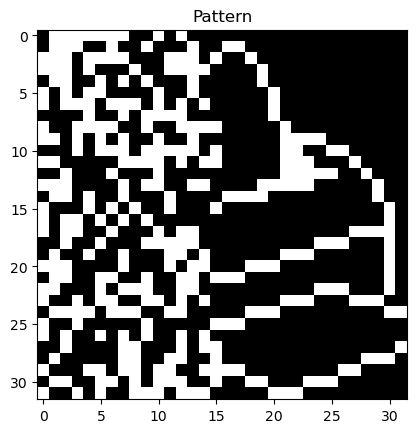

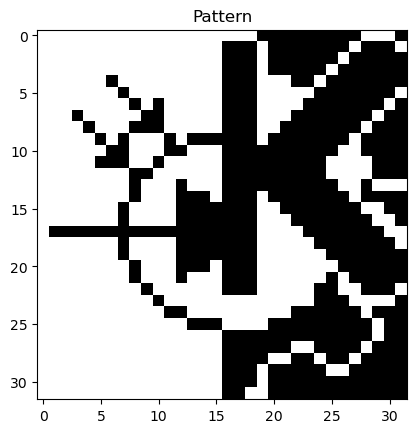

In [21]:
for i, pattern in enumerate(data):
    display_pattern(pattern, f"p{i+1}.pdf")